In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [7]:
df = pd.read_csv("house price prediction.csv")

df.head()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_typeSuper built-up Area,area_typeBuilt-up Area,area_typePlot Area,availability_Ready To Move,...,location_Kalena Agrahara,location_Horamavu Agara,location_Vidyaranyapura,location_BTM 2nd Stage,location_Hebbal Kempapura,location_Hosur Road,location_Horamavu Banaswadi,location_Domlur,location_Mahadevpura,location_Tumkur Road
0,3.0,2.0,150.0,1672.0,3,8971.291866,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,3.0,3.0,149.0,1750.0,3,8514.285714,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3.0,2.0,150.0,1750.0,3,8571.428571,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,2.0,2.0,40.0,1250.0,2,3200.000000,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,2.0,2.0,83.0,1200.0,2,6916.666667,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [8]:
print(df.shape)

df.info()

df.describe()

(7120, 108)
<class 'pandas.DataFrame'>
RangeIndex: 7120 entries, 0 to 7119
Columns: 108 entries, bath to location_Tumkur Road
dtypes: float64(5), int64(103)
memory usage: 5.9 MB


,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_typeSuper built-up Area,area_typeBuilt-up Area,area_typePlot Area,availability_Ready To Move,...,location_Kalena Agrahara,location_Horamavu Agara,location_Vidyaranyapura,location_BTM 2nd Stage,location_Hebbal Kempapura,location_Hosur Road,location_Horamavu Banaswadi,location_Domlur,location_Mahadevpura,location_Tumkur Road
count,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,...,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000
mean,2.390871,1.572759,96.454991,1479.729806,2.465169,5923.806855,0.750702,0.182303,0.061938,0.792697,...,0.003090,0.003090,0.002949,0.002949,0.002949,0.002949,0.002809,0.002809,0.002809,0.002809
std,0.876822,0.770583,116.185034,913.779769,0.841520,2556.650935,0.432637,0.386121,0.241060,0.405403,...,0.055505,0.055505,0.054232,0.054232,0.054232,0.054232,0.052929,0.052929,0.052929,0.052929
min,1.000000,0.000000,10.000000,350.000000,1.000000,1250.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,49.230000,1100.000000,2.000000,4416.761042,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,69.000000,1255.000000,2.000000,5417.855613,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,2.000000,104.000000,1640.250000,3.000000,6618.285651,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9.000000,3.000000,2912.000000,30400.000000,9.000000,35000.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.isnull().sum()

bath                           0
balcony                        0
price                          0
total_sqft_int                 0
bhk                            0
                              ..
location_Hosur Road            0
location_Horamavu Banaswadi    0
location_Domlur                0
location_Mahadevpura           0
location_Tumkur Road           0
Length: 108, dtype: int64

In [10]:
df = df.dropna()

In [11]:
X = df.drop("price", axis=1)

y = df["price"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:
model = Sequential()

model.add(Dense(64,
                activation='relu',
                input_shape=(X_train.shape[1],)))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='linear'))

c:\Users\shubh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 16144.4756 - mae: 66.5726 - val_loss: 10892.0527 - val_mae: 39.7974
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6689.7041 - mae: 30.5989 - val_loss: 7499.9756 - val_mae: 26.3038
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4763.8838 - mae: 23.1877 - val_loss: 5680.7788 - val_mae: 20.7056
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3538.4402 - mae: 20.1723 - val_loss: 4412.9287 - val_mae: 18.2276
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2466.6077 - mae: 16.4797 - val_loss: 3608.1050 - val_mae: 20.2788
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1908.8738 - mae: 16.1424 - val_loss: 3002.5269 - val_mae: 14.6804
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1630.3528 - mae: 13.1125 - val_loss: 2731.8704 - val_mae: 12.9707
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1522.8953 - mae: 11.7096 - val_loss: 2565.8269 - val_mae

In [18]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test MAE  :", mae)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 73.6446 - mae: 4.1547 
Test Loss : 73.64459991455078
Test MAE  : 4.15466833114624


In [19]:
y_pred = model.predict(X_test)

y_pred = y_pred.flatten()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [20]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 4.154667818479323
RMSE : 8.581643240234763
R2 Score : 0.9935132890029378


In [21]:
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

result.head(10)

,Actual Price,Predicted Price
0,47.00,47.183243
1,60.00,57.547279
2,65.00,61.682785
3,325.00,300.083618
4,60.00,55.523792
5,60.00,56.812340
6,53.33,51.139767
7,62.55,62.611206
8,74.00,69.461113
9,560.00,551.822144


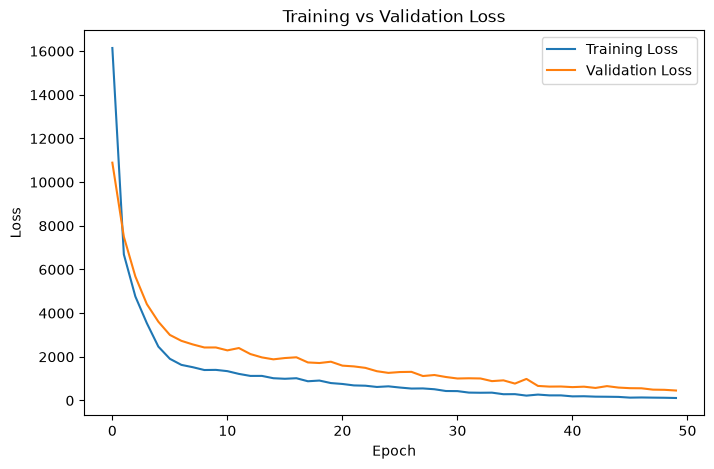

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

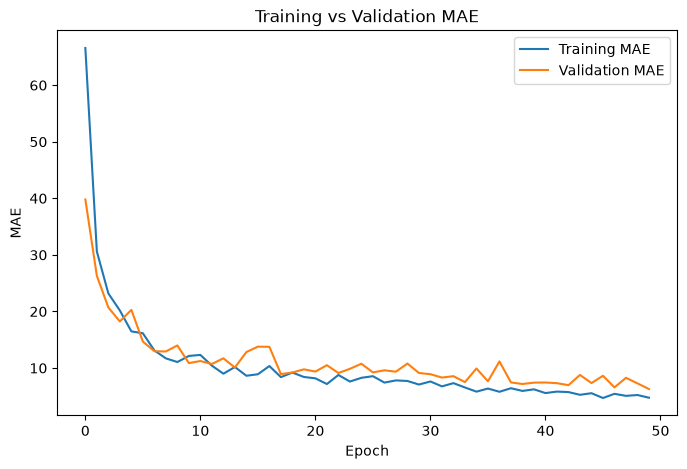

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')

plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.title("Training vs Validation MAE")

plt.legend()

plt.show()

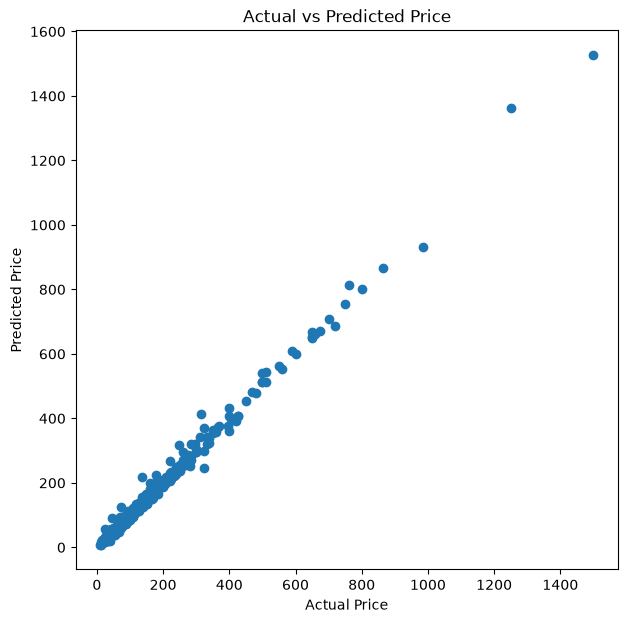

In [24]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()